# Fast Charge Profile Generation with Default Parameters

This notebook demonstrates fast charging using PyBaMM's built-in parameter sets:
- **LFP**: Prada2013 (LFP/Graphite)
- **NMC**: ORegan2022 (NMC/Graphite)

The `run_spmet_default` function accepts a `cell_design` dict that overrides default PyBaMM parameters.

## Fast Charge Protocol
1. Start at 10% SOC
2. Charge at high C-rate until anode potential threshold is reached
3. Ride the anode potential plateau until one of:
   - Maximum charge time (60 minutes)
   - Upper voltage threshold
   - Maximum temperature threshold
4. CV hold until termination current

In [23]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet

## 1. Load Cell Design from Manifest

Load the cell manifest JSON and extract the `cell_design` parameters to override PyBaMM defaults.

In [24]:
# manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
manifest_path = Path("../cells/VW_ID3_Pouch_80Ah_manifest.json")

material_path = Path("../materials")

with open(manifest_path, "r") as f:
    cell_design_manifest = json.load(f)

    # Load material properties
    for component in ["separator", "electrolyte"]:
        material_name = cell_design_manifest["cell_design"][component]["material"][
            "type"
        ]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

    for component in ["negative_electrode", "positive_electrode"]:
        material_name = cell_design_manifest["cell_design"][component]["coating"][
            "formulation"
        ]["primary_active_material"]["name"]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

cell_design = cell_design_manifest["cell_design"]
cell_design["nominal_capacity"] = {
    "value": cell_design_manifest["kpis"]["nominal_capacity"]["value"],
    "unit": "Ah",
}
cell_design["nominal_energy"] = {
    "value": cell_design_manifest["kpis"]["nominal_energy"]["value"],
    "unit": "Wh",
}
cell_design["cell_volume"] = {
    "value": cell_design_manifest["kpis"]["cell_volume"]["value"],
    "unit": "L",
}
cell_design["nominal_voltage"] = {
    "value": cell_design_manifest["kpis"]["nominal_voltage"]["value"],
    "unit": "V",
}
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design["lower_voltage_cutoff"]["value"]
nominal_capacity = cell_design["nominal_capacity"]["value"]
# Load duty cycle
print(f"Cell: {cell_design_manifest['metadata']['name']}")
print(f"Form factor: {cell_design['form_factor']}")
print(f"Capacity: {cell_design['nominal_capacity']['value']:.1f} Ah")
print(f"Energy: {cell_design['nominal_energy']['value']:.1f} Wh")
print(
    f"Nominal voltage: {cell_design_manifest['kpis']['nominal_voltage']['value']:.2f} V"
)
print(
    f"Voltage range: {cell_design['lower_voltage_cutoff']['value']:.2f} - {cell_design['upper_voltage_cutoff']['value']:.2f} V"
)

Cell: VW ID3 Pouch 80Ah
Form factor: Pouch
Capacity: 80.5 Ah
Energy: 295.4 Wh
Nominal voltage: 3.67 V
Voltage range: 2.80 - 4.20 V


## 2. Fast Charge Configuration

In [25]:
# Fast charge parameters
INITIAL_SOC = 0.10  # 10% SOC
CHARGE_C_RATE = 4.0  # 4C charging
ANODE_POTENTIAL_THRESHOLD_V = 0.02  # Lithium plating protection threshold
MAX_CHARGE_TIME_S = 60 * 60  # 60 minutes maximum
MAX_TEMPERATURE_K = 273.15 + 45  # 45C maximum temperature
COOLING_SURFACE_AREA_M2 = 0.001  

print(f"Fast Charge Configuration:")
print(f"  Initial SOC: {INITIAL_SOC*100:.0f}%")
print(f"  Charge C-rate: {CHARGE_C_RATE}C ({CHARGE_C_RATE * nominal_capacity:.1f} A)")
print(f"  Anode potential threshold: {ANODE_POTENTIAL_THRESHOLD_V} V")
print(f"  Max charge time: {MAX_CHARGE_TIME_S/60:.0f} minutes")
print(f"  Max temperature: {MAX_TEMPERATURE_K - 273.15:.0f} C")

Fast Charge Configuration:
  Initial SOC: 10%
  Charge C-rate: 4.0C (322.0 A)
  Anode potential threshold: 0.02 V
  Max charge time: 60 minutes
  Max temperature: 45 C


## 3. Run Fast Charge Simulation

Use `run_spmet_default` with `ride_anode_potential=True` to enable the 3-phase fast charge protocol:
1. CC phase at specified C-rate until anode potential threshold
2. Anode potential riding phase (maintains constant anode potential)
3. CV phase until termination current

In [26]:
# Fast charge simulation config
fast_charge_config = {
    # Thermal conditions
    "ambient_temperature": 298.15,  # 25C
    "initial_temperature": 298.15,  # 25C
    "total_heat_transfer_coefficient": 10.0,  # W.m-2.K-1
    "cooling_surface_area": COOLING_SURFACE_AREA_M2,  # m2
    "contact_resistance": 0.0001,  # Ohm
    # Initial state
    "initial_soc": INITIAL_SOC,
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    # Fast charge specific settings
    "ride_anode_potential": True,  # Enable anode potential riding
    "anode_potential_threshold_V": ANODE_POTENTIAL_THRESHOLD_V,
    "jelly_roll_temperature_threshold_K": MAX_TEMPERATURE_K,
    "max_charge_time_s": MAX_CHARGE_TIME_S,
    "cv_termination_c_rate": 0.05,  # C/20 termination
    # Experiment definition
    "experiments": [f"Charge at {CHARGE_C_RATE}C for {MAX_CHARGE_TIME_S} seconds"],
    "experiment_labels": [f"{CHARGE_C_RATE}C_fast_charge"],
    "period": "1 second",
}

# Run simulation using default parameters with cell_design from manifest
results = run_spmet(cell_design, fast_charge_config)


Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 80.50 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  84.45 Ah, Error =  4.904%
Iteration  2: Capacity =  80.46 Ah, Error =  0.051%
Iteration  3: Capacity =  80.50 Ah, Error =  0.001%
--------------------------------------------------------------------------------
Converged after 3 iterations!

RUNNING EXPERIMENTS

Running: 4.0C_fast_charge
  Experiment: Charge at 4.0C for 3600 seconds
  Completed: 3572 data points


## 4. Analyze Results

In [27]:
# Extract results
r = results[0]

if r['success']:
    time_s = r['time_s']
    voltage_V = r['voltage_V']
    current_A = r['current_A']
    anode_potential_V = r['anode_potential_V']
    temperature_K = r['temperature_K']
    
    # Calculate metrics
    total_time_min = (time_s[-1] - time_s[0]) / 60
    max_temp_C = np.max(temperature_K) - 273.15
    min_anode_potential_V = np.min(anode_potential_V)
    charge_capacity_Ah = np.trapezoid(-current_A, time_s) / 3600
    
    print(f"\nFast Charge Results:")
    print(f"  Total charge time: {total_time_min:.1f} minutes")
    print(f"  Charge capacity: {charge_capacity_Ah:.1f} Ah")
    print(f"  Final voltage: {voltage_V[-1]:.3f} V")
    print(f"  Max temperature: {max_temp_C:.1f} C")
    print(f"  Min anode potential: {min_anode_potential_V:.4f} V")
else:
    print(f"Simulation failed: {r.get('error', 'Unknown error')}")


Fast Charge Results:
  Total charge time: 59.5 minutes
  Charge capacity: 72.8 Ah
  Final voltage: 4.200 V
  Max temperature: 67.3 C
  Min anode potential: -0.3258 V


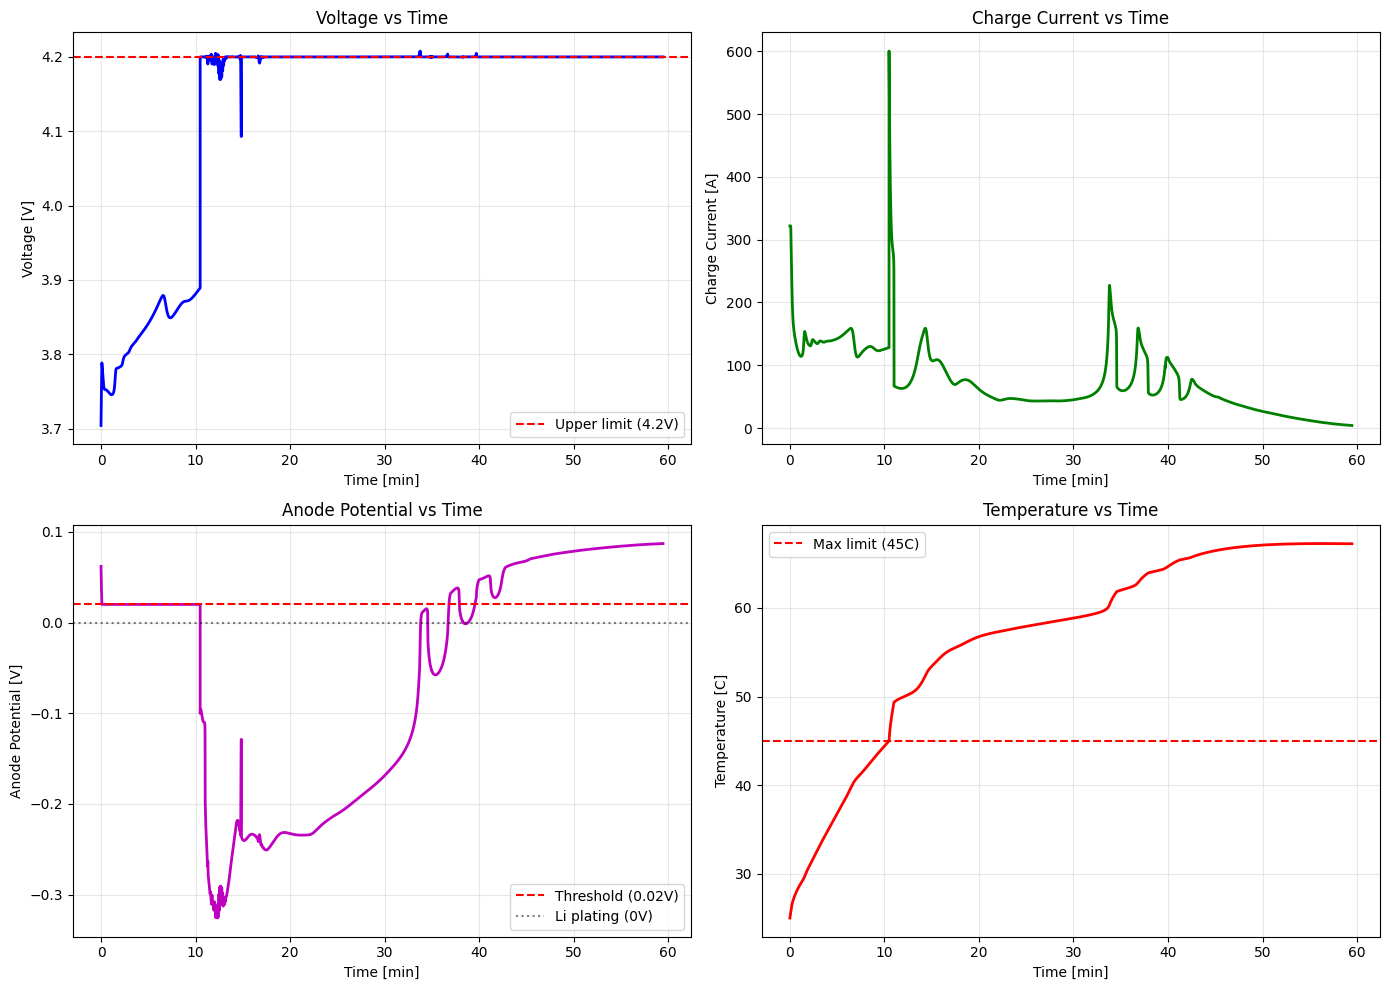

In [28]:
if r['success']:
    # Create comprehensive plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    time_min = (time_s - time_s[0]) / 60

    # Plot 1: Voltage vs Time
    ax1 = axes[0, 0]
    ax1.plot(time_min, voltage_V, 'b-', linewidth=2)
    ax1.axhline(y=upper_voltage_cutoff, color='r', linestyle='--', label=f'Upper limit ({upper_voltage_cutoff}V)')
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Voltage vs Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Current vs Time
    ax2 = axes[0, 1]
    ax2.plot(time_min, -current_A, 'g-', linewidth=2)  # Negative for charge current display
    ax2.set_xlabel('Time [min]')
    ax2.set_ylabel('Charge Current [A]')
    ax2.set_title('Charge Current vs Time')
    ax2.grid(True, alpha=0.3)

    # Plot 3: Anode Potential vs Time
    ax3 = axes[1, 0]
    ax3.plot(time_min, anode_potential_V, 'm-', linewidth=2)
    ax3.axhline(y=ANODE_POTENTIAL_THRESHOLD_V, color='r', linestyle='--', 
                label=f'Threshold ({ANODE_POTENTIAL_THRESHOLD_V}V)')
    ax3.axhline(y=0, color='k', linestyle=':', alpha=0.5, label='Li plating (0V)')
    ax3.set_xlabel('Time [min]')
    ax3.set_ylabel('Anode Potential [V]')
    ax3.set_title('Anode Potential vs Time')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Temperature vs Time
    ax4 = axes[1, 1]
    temp_C = temperature_K - 273.15
    ax4.plot(time_min, temp_C, 'r-', linewidth=2)
    ax4.axhline(y=MAX_TEMPERATURE_K - 273.15, color='r', linestyle='--', 
                label=f'Max limit ({MAX_TEMPERATURE_K - 273.15:.0f}C)')
    ax4.set_xlabel('Time [min]')
    ax4.set_ylabel('Temperature [C]')
    ax4.set_title('Temperature vs Time')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. Compare Multiple C-rates

In [29]:
# Run simulations at different C-rates
c_rates = [1, 2, 4]
all_results = {}

for c_rate in c_rates:
    config = {
        **fast_charge_config,
        "experiments": [f"Charge at {c_rate}C for {MAX_CHARGE_TIME_S} seconds"],
        "experiment_labels": [f"{c_rate}C"],
    }
    
    try:
        res = run_spmet(cell_design, config)
        if res[0]['success']:
            all_results[c_rate] = res[0]
            charge_time = (res[0]['time_s'][-1] - res[0]['time_s'][0]) / 60
            print(f"  {c_rate}C: {charge_time:.1f} min")
        else:
            print(f"  {c_rate}C: Failed - {res[0].get('error', 'Unknown')[:50]}")
    except Exception as e:
        print(f"  {c_rate}C: Error - {str(e)[:50]}")


Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 80.50 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  84.45 Ah, Error =  4.904%
Iteration  2: Capacity =  80.46 Ah, Error =  0.051%
Iteration  3: Capacity =  80.50 Ah, Error =  0.001%
--------------------------------------------------------------------------------
Converged after 3 iterations!

RUNNING EXPERIMENTS

Running: 1C
  Experiment: Charge at 1C for 3600 seconds
  Completed: 3604 data points
  1C: 60.0 min

Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 80.50 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  84.45 Ah, Error =  4.904%
Iteration  2: Capacity =  80.46 Ah, Error =  0.051%
Iteration  3: Capacity =  80.50 Ah, Error =  0.001%
------------------------------------------------

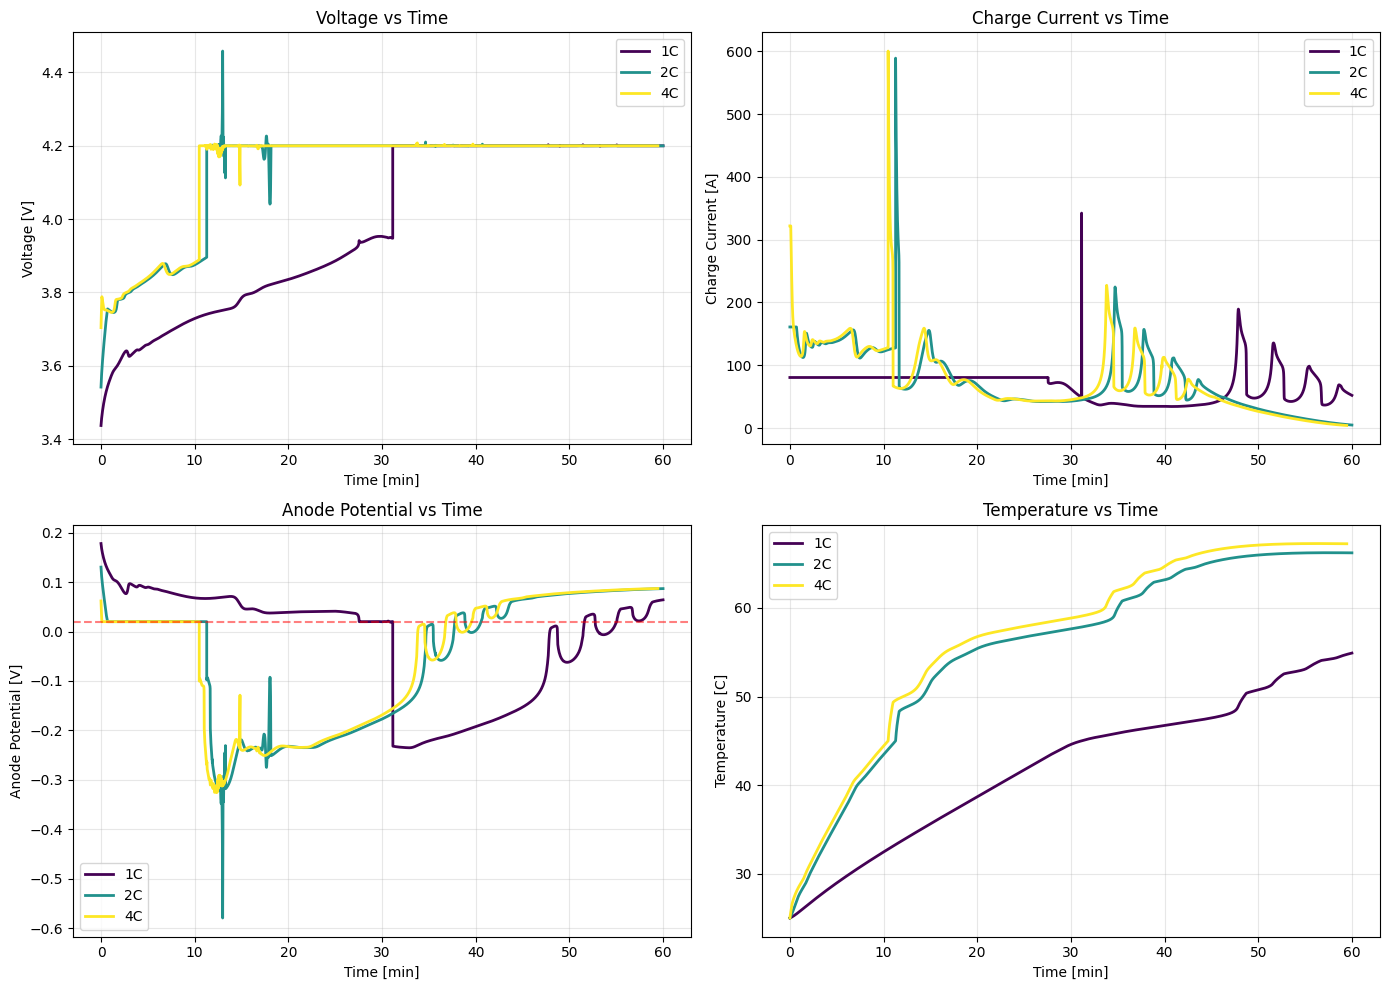

In [31]:
# Compare C-rates
if len(all_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(all_results)))
    
    for (c_rate, data), color in zip(all_results.items(), colors):
        time_min = (data['time_s'] - data['time_s'][0]) / 60
        
        # Voltage
        axes[0, 0].plot(time_min, data['voltage_V'], color=color, 
                        linewidth=2, label=f'{c_rate}C')
        
        # Current
        axes[0, 1].plot(time_min, -data['current_A'], color=color, 
                        linewidth=2, label=f'{c_rate}C')
        
        # Anode potential
        axes[1, 0].plot(time_min, data['anode_potential_V'], color=color, 
                        linewidth=2, label=f'{c_rate}C')
        
        # Temperature
        axes[1, 1].plot(time_min, data['temperature_K'] - 273.15, color=color, 
                        linewidth=2, label=f'{c_rate}C')
    
    axes[0, 0].set_xlabel('Time [min]')
    axes[0, 0].set_ylabel('Voltage [V]')
    axes[0, 0].set_title('Voltage vs Time')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_xlabel('Time [min]')
    axes[0, 1].set_ylabel('Charge Current [A]')
    axes[0, 1].set_title('Charge Current vs Time')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_xlabel('Time [min]')
    axes[1, 0].set_ylabel('Anode Potential [V]')
    axes[1, 0].set_title('Anode Potential vs Time')
    axes[1, 0].axhline(y=ANODE_POTENTIAL_THRESHOLD_V, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_xlabel('Time [min]')
    axes[1, 1].set_ylabel('Temperature [C]')
    axes[1, 1].set_title('Temperature vs Time')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()